In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [129]:
df = pd.read_csv('../data/processed/cleaned_data.csv')

C:\Users\Faisal\AppData\Local\Temp\ipykernel_28564\2460883332.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/cleaned_data.csv')


In [130]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    524878 non-null  object 
 1   StockCode    524878 non-null  object 
 2   Description  524878 non-null  object 
 3   Quantity     524878 non-null  int64  
 4   InvoiceDate  524878 non-null  object 
 5   UnitPrice    524878 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      524878 non-null  object 
 8   Revenue      524878 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 36.0+ MB


In [132]:
print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


## Recency

In [133]:
rfm_df = df.dropna(subset=['CustomerID']).copy()

In [134]:
rfm_df.shape

(392692, 9)

In [135]:
rfm_df['InvoiceDate'] = pd.to_datetime(rfm_df['InvoiceDate'])

In [136]:
print(rfm_df['InvoiceDate'].dtype)

datetime64[ns]


In [137]:
reference_date = rfm_df['InvoiceDate'].max()

In [138]:
reference_date

Timestamp('2011-12-09 12:50:00')

In [139]:
last_purchase = rfm_df.groupby('CustomerID')['InvoiceDate'].max()

In [140]:
recency = (reference_date - last_purchase).dt.days

In [141]:
recency.head(10)

CustomerID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
12352.0     35
12353.0    203
12354.0    231
12355.0    213
12356.0     22
Name: InvoiceDate, dtype: int64

## Frequency

In [142]:
frequency = rfm_df.groupby('CustomerID')['InvoiceNo'].nunique()

In [143]:
frequency.head(10)

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
12352.0    8
12353.0    1
12354.0    1
12355.0    1
12356.0    3
Name: InvoiceNo, dtype: int64

## Monetary

In [144]:
monetary = rfm_df.groupby('CustomerID')['Revenue'].sum()
monetary.head()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: Revenue, dtype: float64

In [145]:
rfm = pd.DataFrame({
    "Recency" : recency,
    "Frequency" : frequency,
    "Monetary" : monetary
})

In [146]:
rfm.head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40
12352.0,35,8,2506.04
12353.0,203,1,89.00
12354.0,231,1,1079.40
12355.0,213,1,459.40


In [147]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272245,2048.688081
std,100.014169,7.697975,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


In [148]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

rfm[['Recency', 'R_Score']].head(10)

,Recency,R_Score
CustomerID,,
12346.0,325,1
12347.0,1,5
12348.0,74,2
12349.0,18,4
12350.0,309,1
12352.0,35,3
12353.0,203,1
12354.0,231,1
12355.0,213,1


In [149]:
rfm['Frequency'].value_counts().sort_index().head(20)

Frequency
1     1493
2      835
3      507
4      389
5      242
6      172
7      143
8       98
9       68
10      54
11      52
12      45
13      30
14      20
15      28
16      11
17      18
18      14
19      12
20      12
Name: count, dtype: int64

In [150]:
rfm['F_Score'] = pd.cut(
    rfm['Frequency'],
    bins=[0, 1, 2, 4, 10, float('inf')],
    labels=[1, 2, 3, 4, 5]
)

In [151]:
rfm[['Frequency', 'F_Score']].head(10)

,Frequency,F_Score
CustomerID,,
12346.0,1,1
12347.0,7,4
12348.0,4,3
12349.0,1,1
12350.0,1,1
12352.0,8,4
12353.0,1,1
12354.0,1,1
12355.0,1,1


In [152]:
rfm['M_Score'] = pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])
rfm[['Monetary','M_Score']].head(10)

,Monetary,M_Score
CustomerID,,
12346.0,77183.60,5
12347.0,4310.00,5
12348.0,1797.24,4
12349.0,1757.55,4
12350.0,334.40,2
12352.0,2506.04,5
12353.0,89.00,1
12354.0,1079.40,4
12355.0,459.40,2


In [153]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

In [154]:
rfm.columns

Index(['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score',
       'RFM_Score'],
      dtype='object')

In [155]:
rfm[['Recency', 'Frequency', 'Monetary',
     'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,325,1,77183.60,1,1,5,115
12347.0,1,7,4310.00,5,4,5,545
12348.0,74,4,1797.24,2,3,4,234
12349.0,18,1,1757.55,4,1,4,414
12350.0,309,1,334.40,1,1,2,112
12352.0,35,8,2506.04,3,4,5,345
12353.0,203,1,89.00,1,1,1,111
12354.0,231,1,1079.40,1,1,4,114
12355.0,213,1,459.40,1,1,2,112


In [156]:
rfm['RFM_Score'].value_counts().sort_index()

RFM_Score
111    331
112    206
113     59
114     21
115      4
      ... 
543     17
544    114
545    149
554      6
555    218
Name: count, Length: 105, dtype: int64

In [161]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'

    elif r >= 4 and f <= 2 and m >= 2:
        return 'Potential Loyalists'

    elif r >= 4 and f == 1 and m <= 2:
        return 'New Customers'

    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'

    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customers'

    else:
        return 'Need Attention'

In [162]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [163]:
rfm['Segment'].value_counts()

Segment
Need Attention         1024
Lost Customers          948
Champions               795
Loyal Customers         761
Potential Loyalists     362
At Risk                 320
New Customers           128
Name: count, dtype: int64

In [160]:
rfm[rfm['Segment'] == 'Others'][
    ['R_Score', 'F_Score', 'M_Score', 'RFM_Score']
].value_counts().head(20)

R_Score  F_Score  M_Score  RFM_Score
3        1        1        311          129
                  2        312          104
2        2        3        223           89
3        3        4        334           77
                  3        333           77
         2        3        323           71
2        1        3        213           61
1        1        3        113           59
3        2        2        322           54
1        2        3        123           48
3        1        3        313           42
2        2        4        224           37
3        3        5        335           31
2        3        2        232           29
3        2        4        324           27
2        1        4        214           22
3        2        1        321           22
1        2        4        124           22
         1        4        114           21
4        2        1        421           20
Name: count, dtype: int64

In [167]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values()
segment_revenue

Segment
New Customers            19198.420
Lost Customers          224610.451
Potential Loyalists     406418.200
At Risk                 618367.431
Need Attention          747160.121
Loyal Customers        1390702.441
Champions              5480751.830
Name: Monetary, dtype: float64

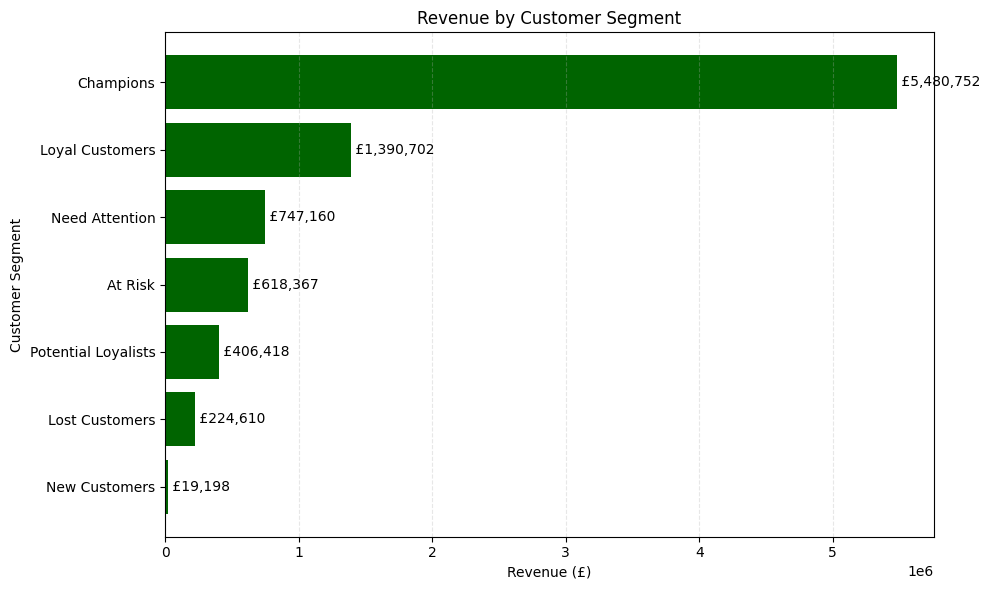

In [174]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    segment_revenue.index,
    segment_revenue.values,
    color="darkgreen"
)

plt.xlabel("Revenue (£)")
plt.ylabel("Customer Segment")
plt.title("Revenue by Customer Segment")

plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f" £{bar.get_width():,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Revenue by Segment

- **Champions** bring in the highest revenue, around **£5.48 million**, which is about **61.67%** of the total RFM revenue.
- **Loyal Customers** generate around **£1.39 million**, making up about **15.65%** of the revenue.
- **Need Attention** and **At Risk** customers together contribute around **15.37%** of the revenue. These customers are still valuable, but their buying behaviour needs more attention.
- **Potential Loyalists** contribute around **£406K** and could become more valuable if they continue purchasing.
- **Lost Customers** have generated around **£225K** in the past, even though they are not buying recently.
- **New Customers** currently contribute the least revenue, around **£19K**, which is expected because they have only recently started purchasing.
- Overall, a large part of the revenue comes from **Champions and Loyal Customers**, showing that repeat and high-value customers are very important to the business.